h = 0.01   avg y = 1.910162   avg error = 0.369016   y at x~15 = 0.232490   local error at x~15 = 0.041061
h = 0.05   avg y = 1.017822   avg error = 1.259729   y at x~15 = 0.121312   local error at x~15 = 0.154240
h = 0.15   avg y = 0.319782   avg error = 1.953710   y at x~15 = 0.021963   local error at x~15 = 0.263966
h = 0.20   avg y = 0.204473   avg error = 2.067014   y at x~15 = 0.007995   local error at x~15 = 0.267557
h = 0.25   avg y = 0.135797   avg error = 2.133632   y at x~15 = 0.003014   local error at x~15 = 0.305629
h = 0.30   avg y = 0.091256   avg error = 2.176142   y at x~15 = 0.000888   local error at x~15 = 0.320171
h = 0.35   avg y = 0.060849   avg error = 2.204518   y at x~15 = 0.000146   local error at x~15 = 0.213247
h = 0.40   avg y = 0.039498   avg error = 2.223890   y at x~15 = 0.000021   local error at x~15 = 0.236338
h = 0.45   avg y = 0.025016   avg error = 2.236290   y at x~15 = 0.000001   local error at x~15 = 0.283036
h = 0.50   avg y = 0.015873   avg err

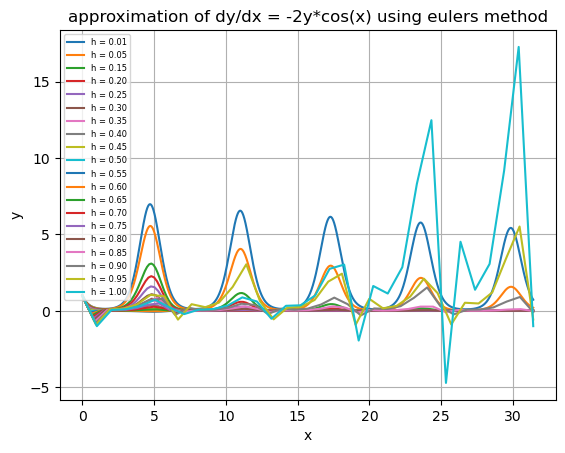

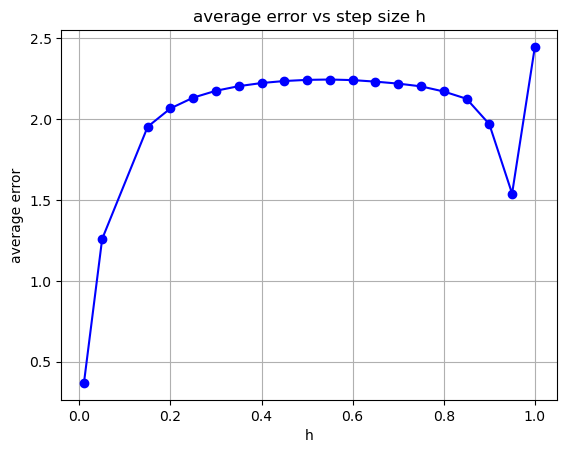

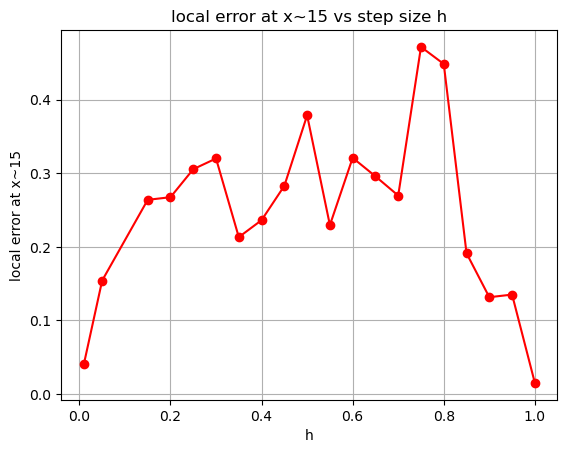

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math
import time 

x_start = 0
x_end = 10 * np.pi
step_sizes = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
 
def f(x, y):
    return -2 * y * np.cos(x)
 
def exact_solution(x):
    return np.exp(-2 * np.sin(x))
 
avg_errors = []
local_errors = []
h_values = []
 
plt.figure()
 
for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1
 
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
 
    y_exact = exact_solution(x_values)
    errors = np.abs(y_values - y_exact)
 
    avg_y = np.mean(y_values)
    avg_error = np.mean(errors)
    avg_errors.append(avg_error)
    h_values.append(h)
 
    idx_15 = np.argmin(np.abs(x_values - 15))
    local_error = np.abs(y_values[idx_15] - y_exact[idx_15])
    local_errors.append(local_error)
 
    print(f"h = {h:.2f}   avg y = {avg_y:.6f}   avg error = {avg_error:.6f}   y at x~15 = {y_values[idx_15]:.6f}   local error at x~15 = {local_error:.6f}")
 
    plt.plot(x_values, y_values, label=f"h = {h:.2f}")
 
plt.xlabel("x")
plt.ylabel("y")
plt.title("approximation of dy/dx = -2y*cos(x) using eulers method")
plt.legend(fontsize=6)
plt.grid(True)
plt.show()
 
plt.figure()
plt.plot(h_values, avg_errors, "bo-")
plt.xlabel("h")
plt.ylabel("average error")
plt.title("average error vs step size h")
plt.grid(True)
plt.show()
 
plt.figure()
plt.plot(h_values, local_errors, "ro-")
plt.xlabel("h")
plt.ylabel("local error at x~15")
plt.title("local error at x~15 vs step size h")
plt.grid(True)
plt.show()
 

 
print()


# summary

Here we see that a smaller step size leads to more regular oscilations and a stable looking graph. as we begin to add larger step sizes, the larger oscilations lead to divergence. the increased step size is tricker since the ODE now depends on two variables. this shows the tradeoff with eulers method where a small h gives you more accuracy but costs more in computation. I'm not sure why there is a sudden dip in error around .8 step size, I figured it may be cause it since it is oscilating as some point there may be some sort of deconstructive interference here cancelling out error before spiking back up around a step size of one.

# Here is the addendum which we were told to add to this homework even though its separte but worth double from the points from what I remember 

we are combining the worst case lambda which is just the coefficient to our ODE. we have also seen lambda in in lagrangian multipliers which was also a constant. it tells us if our solution is growing or decaying in this situation 

In [2]:
lambda_eff = -2
stability_limit = 2 / abs(lambda_eff)
 
print()
print("--- Stability Analysis ---")
print(f"f(x,y) = -2y*cos(x)")
print(f"lambda = -2*cos(x), ranges from -2 to 2")
print(f"worst case lambda = {lambda_eff} when cos(x) = 1")
print(f"stability condition: h <= 2/|lambda| = {stability_limit}")
print()
 
for h in step_sizes:
    if h <= stability_limit:
        print(f"h = {h:.2f} -> stable")
    else:
        print(f"h = {h:.2f} -> unstable")
 


--- Stability Analysis ---
f(x,y) = -2y*cos(x)
lambda = -2*cos(x), ranges from -2 to 2
worst case lambda = -2 when cos(x) = 1
stability condition: h <= 2/|lambda| = 1.0

h = 0.01 -> stable
h = 0.05 -> stable
h = 0.15 -> stable
h = 0.20 -> stable
h = 0.25 -> stable
h = 0.30 -> stable
h = 0.35 -> stable
h = 0.40 -> stable
h = 0.45 -> stable
h = 0.50 -> stable
h = 0.55 -> stable
h = 0.60 -> stable
h = 0.65 -> stable
h = 0.70 -> stable
h = 0.75 -> stable
h = 0.80 -> stable
h = 0.85 -> stable
h = 0.90 -> stable
h = 0.95 -> stable
h = 1.00 -> stable
